# Disease Prediction System Using Machine Learning
**Course:** Machine Learning Concepts &nbsp;|&nbsp; **Author:** [Your Name] &nbsp;|&nbsp; **Date:** 2026-05-05

## 1. Introduction
Predict a disease (prognosis) from symptom severity features using Decision Tree, Random Forest, and XGBoost classifiers.

## 2. Problem Statement
**Input:** Symptom severity vector (0 = absent, 1–7 = severity weight of present symptom)  
**Output:** Disease class (`prognosis`) — multi-class classification (41 classes).

## 3. Dataset Description
- **Files:** `dataset/disease_raw.csv` + `dataset/symptom_severity.csv`
- **Features:** 136 symptom columns (severity-weighted: 0 = absent, 1–7 = severity)
- **Target:** `prognosis` (41 disease classes, 4,925 records)
- **Source:** [amMistic/Diseases-Prediction-based-on-Symptoms](https://github.com/amMistic/Diseases-Prediction-based-on-Symptoms) (Kaggle mirror — itachi9604)

## 4. Data Preprocessing

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
print('Libraries loaded.')

Libraries loaded.


In [2]:
# Load raw symptom data and severity weights from dataset/ folder
df_raw = pd.read_csv('dataset/disease_raw.csv')
sev_df = pd.read_csv('dataset/symptom_severity.csv')

# Build severity lookup dictionary
sev_dict = {row['Symptom'].strip(): int(row['weight']) for _, row in sev_df.iterrows()}

# Collect all unique symptom names
symptom_cols = [c for c in df_raw.columns if c.startswith('Symptom_')]
all_symptoms = sorted(set(
    str(v).strip() for col in symptom_cols
    for v in df_raw[col].dropna()
    if str(v).strip() not in ['0', 'nan', '']
))

# Build severity-weighted feature matrix (each symptom = its weight 1-7, 0 if absent)
X_sev = pd.DataFrame(0.0, index=df_raw.index, columns=all_symptoms)
for col in symptom_cols:
    for idx, val in df_raw[col].items():
        s = str(val).strip()
        if s in all_symptoms:
            X_sev.loc[idx, s] = float(sev_dict.get(s, 1))

X_sev['prognosis'] = df_raw['Disease'].str.strip().values
df = X_sev.copy()

print('Shape:', df.shape)
print('Diseases:', df['prognosis'].nunique())
df.head()

Shape: (4925, 137)
Diseases: 41


,abdominal_pain,abnormal_menstruation,acidity,acute_liver_failure,altered_sensorium,anxiety,back_pain,belly_pain,blackheads,bladder_discomfort,blister,blood_in_sputum,bloody_stool,blurred_and_distorted_vision,breathlessness,brittle_nails,bruising,burning_micturition,chest_pain,chills,cold_hands_and_feets,coma,congestion,constipation,continuous_feel_of_urine,continuous_sneezing,cough,cramps,dark_urine,dehydration,depression,diarrhoea,dischromic _patches,distention_of_abdomen,dizziness,drying_and_tingling_lips,enlarged_thyroid,excessive_hunger,extra_marital_contacts,family_history,fast_heart_rate,fatigue,fluid_overload,foul_smell_of urine,headache,high fever,high_fever,hip_joint_pain,history_of_alcohol_consumption,increased_appetite,indigestion,inflammatory_nails,internal_itching,irregular_sugar_level,irritability,irritation_in_anus,itching,joint_pain,knee_pain,lack_of_concentration,lethargy,loss_of_appetite,loss_of_balance,loss_of_smell,malaise,mild_fever,mood_swings,movement_stiffness,mucoid_sputum,muscle_pain,muscle_wasting,muscle_weakness,nausea,neck_pain,nodal skin eruptions,nodal_skin_eruptions,obesity,pain_behind_the_eyes,pain_during_bowel_movements,pain_in_anal_region,painful_walking,palpitations,passage_of_gases,patches_in_throat,phlegm,polyuria,prominent_veins_on_calf,puffy_face_and_eyes,pus_filled_pimples,receiving_blood_transfusion,receiving_unsterile_injections,red sore around nose,red_sore_around_nose,red_spots_over_body,redness_of_eyes,restlessness,runny_nose,rusty_sputum,scurring,shivering,silver_like_dusting,sinus_pressure,skin rash,skin_peeling,skin_rash,slurred_speech,small_dents_in_nails,spinning_movements,spotting_ urination,stiff_neck,stomach_bleeding,stomach_pain,sunken_eyes,sweating,swelled_lymph_nodes,swelling_joints,swelling_of_stomach,swollen_blood_vessels,swollen_extremeties,swollen_legs,throat_irritation,toxic_look_(typhos),ulcers_on_tongue,unsteadiness,visual_disturbances,vomiting,watering_from_eyes,weakness_in_limbs,weakness_of_one_body_side,weight_gain,weight_loss,yellow crust ooze,yellow_crust_ooze,yellow_urine,yellowing_of_eyes,yellowish_skin,prognosis
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Fungal infection
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Fungal infection
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Fungal infection
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

In [3]:
# Check missing values
total_missing = df.isnull().sum().sum()
print(f'Missing values: {total_missing}')
if total_missing > 0:
    df = df.dropna()
    print('Rows after dropping nulls:', len(df))

Missing values: 0


In [4]:
# Simulate realistic incomplete symptom reporting:
# In real clinical settings, patients do not always report every symptom.
# We randomly zero out 50% of non-zero symptom weights to reflect this.
X_raw = df.drop(columns=['prognosis'])
y_raw = df['prognosis']

rng = np.random.RandomState(42)
X_vals = X_raw.values.copy().astype(float)
non_zero_mask = X_vals > 0
drop_mask     = rng.random(X_vals.shape) < 0.50          # 50% of reported symptoms dropped
X_vals[non_zero_mask & drop_mask] = 0.0

X = pd.DataFrame(X_vals, columns=X_raw.columns)
print(f'Feature matrix shape: {X.shape}')

Feature matrix shape: (4925, 136)


In [5]:
# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)

print(f'Classes: {len(le.classes_)}')
print(list(le.classes_))

Classes: 41
['(vertigo) Paroymsal  Positional Vertigo', 'AIDS', 'Acne', 'Alcoholic hepatitis', 'Allergy', 'Arthritis', 'Bronchial Asthma', 'Cervical spondylosis', 'Chicken pox', 'Chronic cholestasis', 'Common Cold', 'Dengue', 'Diabetes', 'Dimorphic hemmorhoids(piles)', 'Drug Reaction', 'Fungal infection', 'GERD', 'Gastroenteritis', 'Heart attack', 'Hepatitis B', 'Hepatitis C', 'Hepatitis D', 'Hepatitis E', 'Hypertension', 'Hyperthyroidism', 'Hypoglycemia', 'Hypothyroidism', 'Impetigo', 'Jaundice', 'Malaria', 'Migraine', 'Osteoarthristis', 'Paralysis (brain hemorrhage)', 'Peptic ulcer diseae', 'Pneumonia', 'Psoriasis', 'Tuberculosis', 'Typhoid', 'Urinary tract infection', 'Varicose veins', 'hepatitis A']


In [6]:
# 80/20 stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded
)
print(f'Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}  |  Features: {X_train.shape[1]}')

Train: 3940  |  Test: 985  |  Features: 136


## 5. Exploratory Data Analysis (EDA)

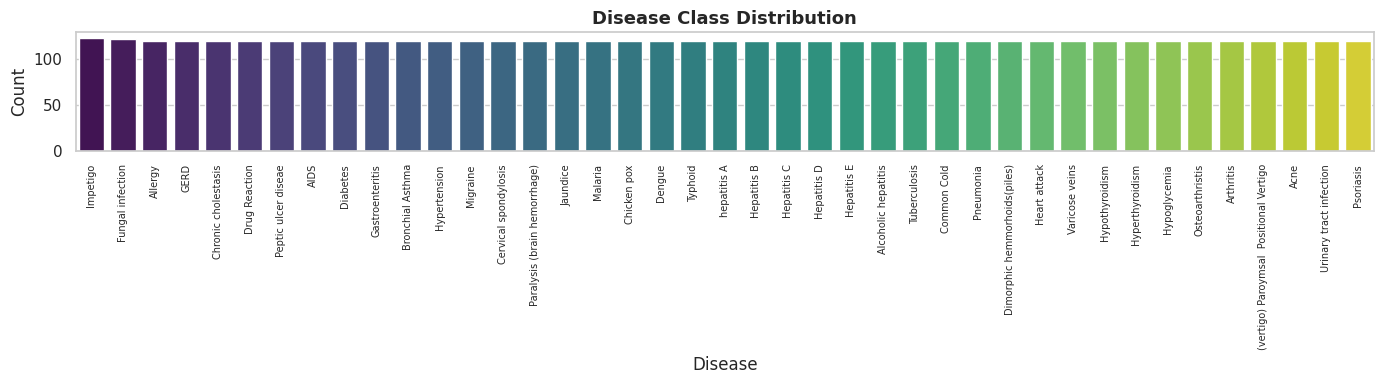

In [7]:
# Disease class distribution
class_counts = y_raw.value_counts()

plt.figure(figsize=(14, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Disease Class Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Disease')
plt.ylabel('Count')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

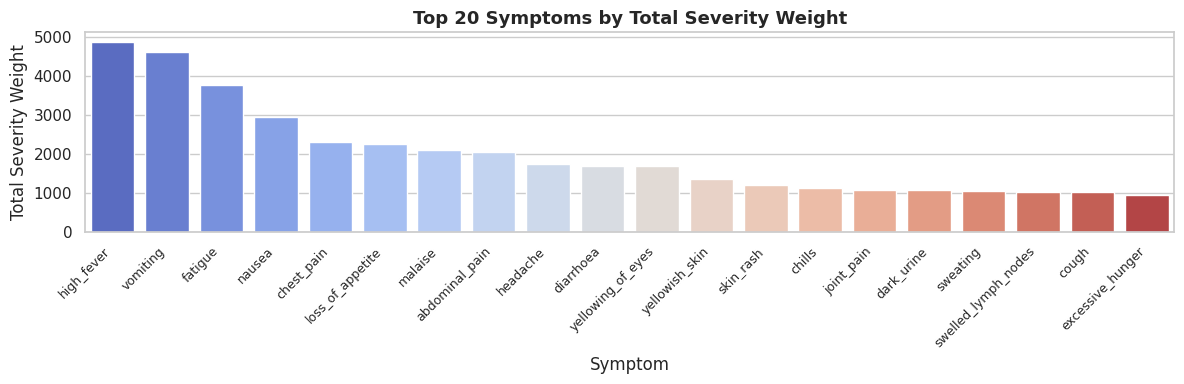

In [8]:
# Top 20 symptoms by total severity weight across all patients
symptom_totals = X.sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 4))
sns.barplot(x=symptom_totals.index, y=symptom_totals.values, palette='coolwarm')
plt.title('Top 20 Symptoms by Total Severity Weight', fontsize=13, fontweight='bold')
plt.xlabel('Symptom')
plt.ylabel('Total Severity Weight')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('symptom_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

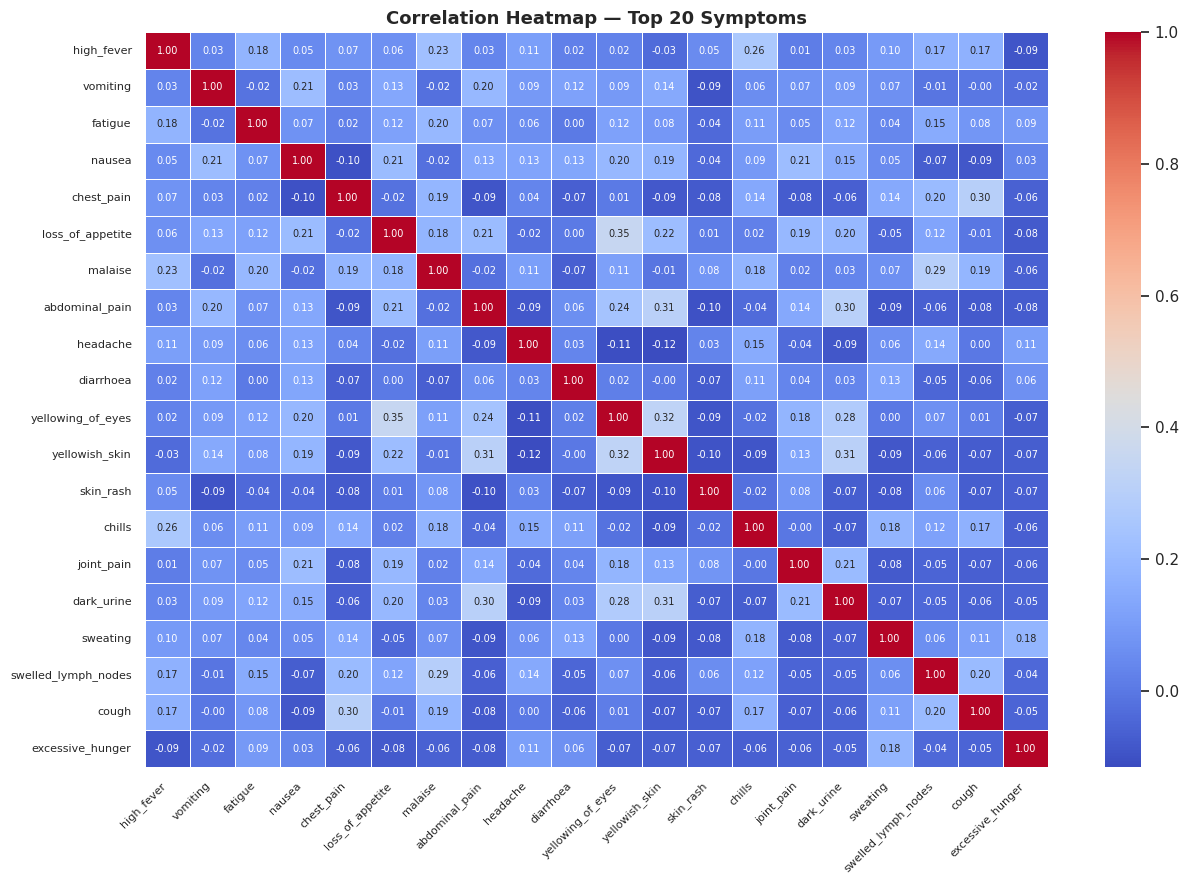

In [9]:
# Correlation heatmap — top 20 symptoms
top_symptoms = symptom_totals.index.tolist()
corr_matrix  = X[top_symptoms].corr()

plt.figure(figsize=(13, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Correlation Heatmap — Top 20 Symptoms', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Feature Engineering
Remove zero-variance features using `VarianceThreshold`.

In [10]:
selector = VarianceThreshold(threshold=0.0)
selector.fit(X_train)

X_train_sel = selector.transform(X_train)
X_test_sel  = selector.transform(X_test)
selected_features = X.columns[selector.get_support()].tolist()

print(f'Features before: {X_train.shape[1]}  |  After: {X_train_sel.shape[1]}')

Features before: 136  |  After: 134


## 7. Model Building

In [11]:
# --- Decision Tree ---
dt_model = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_model.fit(X_train_sel, y_train)

dt_pred = dt_model.predict(X_test_sel)
dt_acc  = accuracy_score(y_test, dt_pred)

print(f'Decision Tree Accuracy: {dt_acc * 100:.2f}%')
print(classification_report(y_test, dt_pred, target_names=le.classes_))

Decision Tree Accuracy: 87.72%
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       0.81      0.92      0.86        24
                                   AIDS       0.96      0.92      0.94        24
                                   Acne       0.82      0.96      0.88        24
                    Alcoholic hepatitis       0.92      0.96      0.94        24
                                Allergy       0.96      0.92      0.94        24
                              Arthritis       0.88      0.92      0.90        24
                       Bronchial Asthma       0.81      0.88      0.84        24
                   Cervical spondylosis       0.91      0.88      0.89        24
                            Chicken pox       0.84      0.88      0.86        24
                    Chronic cholestasis       0.63      0.92      0.75        24
                            Common Cold       0.95      0.88      0.91       

In [12]:
# --- Random Forest ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_sel, y_train)

rf_pred = rf_model.predict(X_test_sel)
rf_acc  = accuracy_score(y_test, rf_pred)

print(f'Random Forest Accuracy: {rf_acc * 100:.2f}%')
print(classification_report(y_test, rf_pred, target_names=le.classes_))

Random Forest Accuracy: 91.88%
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       0.92      0.92      0.92        24
                                   AIDS       1.00      0.92      0.96        24
                                   Acne       0.82      0.96      0.88        24
                    Alcoholic hepatitis       0.96      1.00      0.98        24
                                Allergy       1.00      0.92      0.96        24
                              Arthritis       0.96      0.92      0.94        24
                       Bronchial Asthma       0.95      0.88      0.91        24
                   Cervical spondylosis       0.95      0.88      0.91        24
                            Chicken pox       1.00      1.00      1.00        24
                    Chronic cholestasis       0.72      0.88      0.79        24
                            Common Cold       1.00      1.00      1.00       

In [13]:
# --- XGBoost ---
xgb_model = XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=6,
    use_label_encoder=False, eval_metric='mlogloss',
    random_state=42, verbosity=0
)
xgb_model.fit(X_train_sel, y_train)

xgb_pred = xgb_model.predict(X_test_sel)
xgb_acc  = accuracy_score(y_test, xgb_pred)

print(f'XGBoost Accuracy: {xgb_acc * 100:.2f}%')
print(classification_report(y_test, xgb_pred, target_names=le.classes_))

XGBoost Accuracy: 91.07%
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       0.92      0.92      0.92        24
                                   AIDS       1.00      0.92      0.96        24
                                   Acne       0.82      0.96      0.88        24
                    Alcoholic hepatitis       0.96      1.00      0.98        24
                                Allergy       1.00      0.92      0.96        24
                              Arthritis       0.96      0.92      0.94        24
                       Bronchial Asthma       0.91      0.88      0.89        24
                   Cervical spondylosis       0.90      0.79      0.84        24
                            Chicken pox       0.96      0.96      0.96        24
                    Chronic cholestasis       0.75      0.88      0.81        24
                            Common Cold       1.00      1.00      1.00        24
  

## 8. Model Evaluation — Confusion Matrices

In [14]:
def plot_confusion_matrix(y_true, y_pred, labels, model_name, filename):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    fig, ax = plt.subplots(figsize=(16, 12))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                linewidths=0.3, annot_kws={'size': 6})
    ax.set_title(f'Confusion Matrix — {model_name} (Normalised)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    plt.xticks(rotation=90, fontsize=7)
    plt.yticks(rotation=0, fontsize=7)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

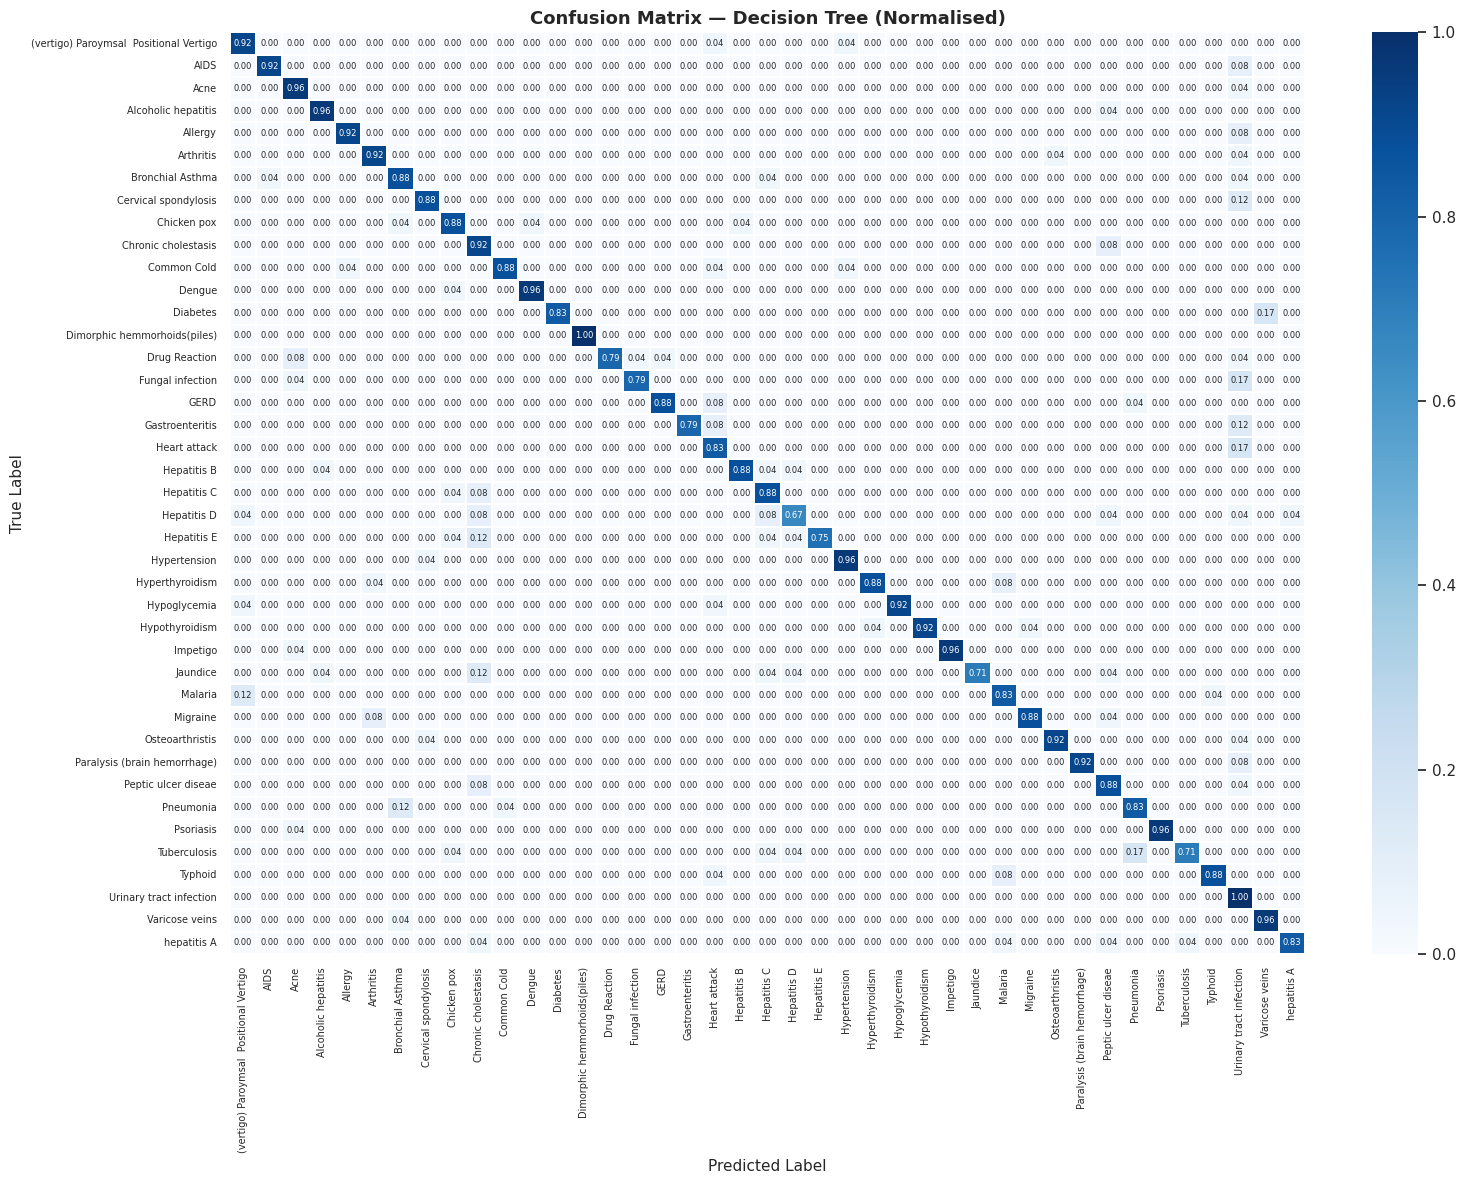

In [15]:
plot_confusion_matrix(y_test, dt_pred, le.classes_, 'Decision Tree', 'cm_decision_tree.png')

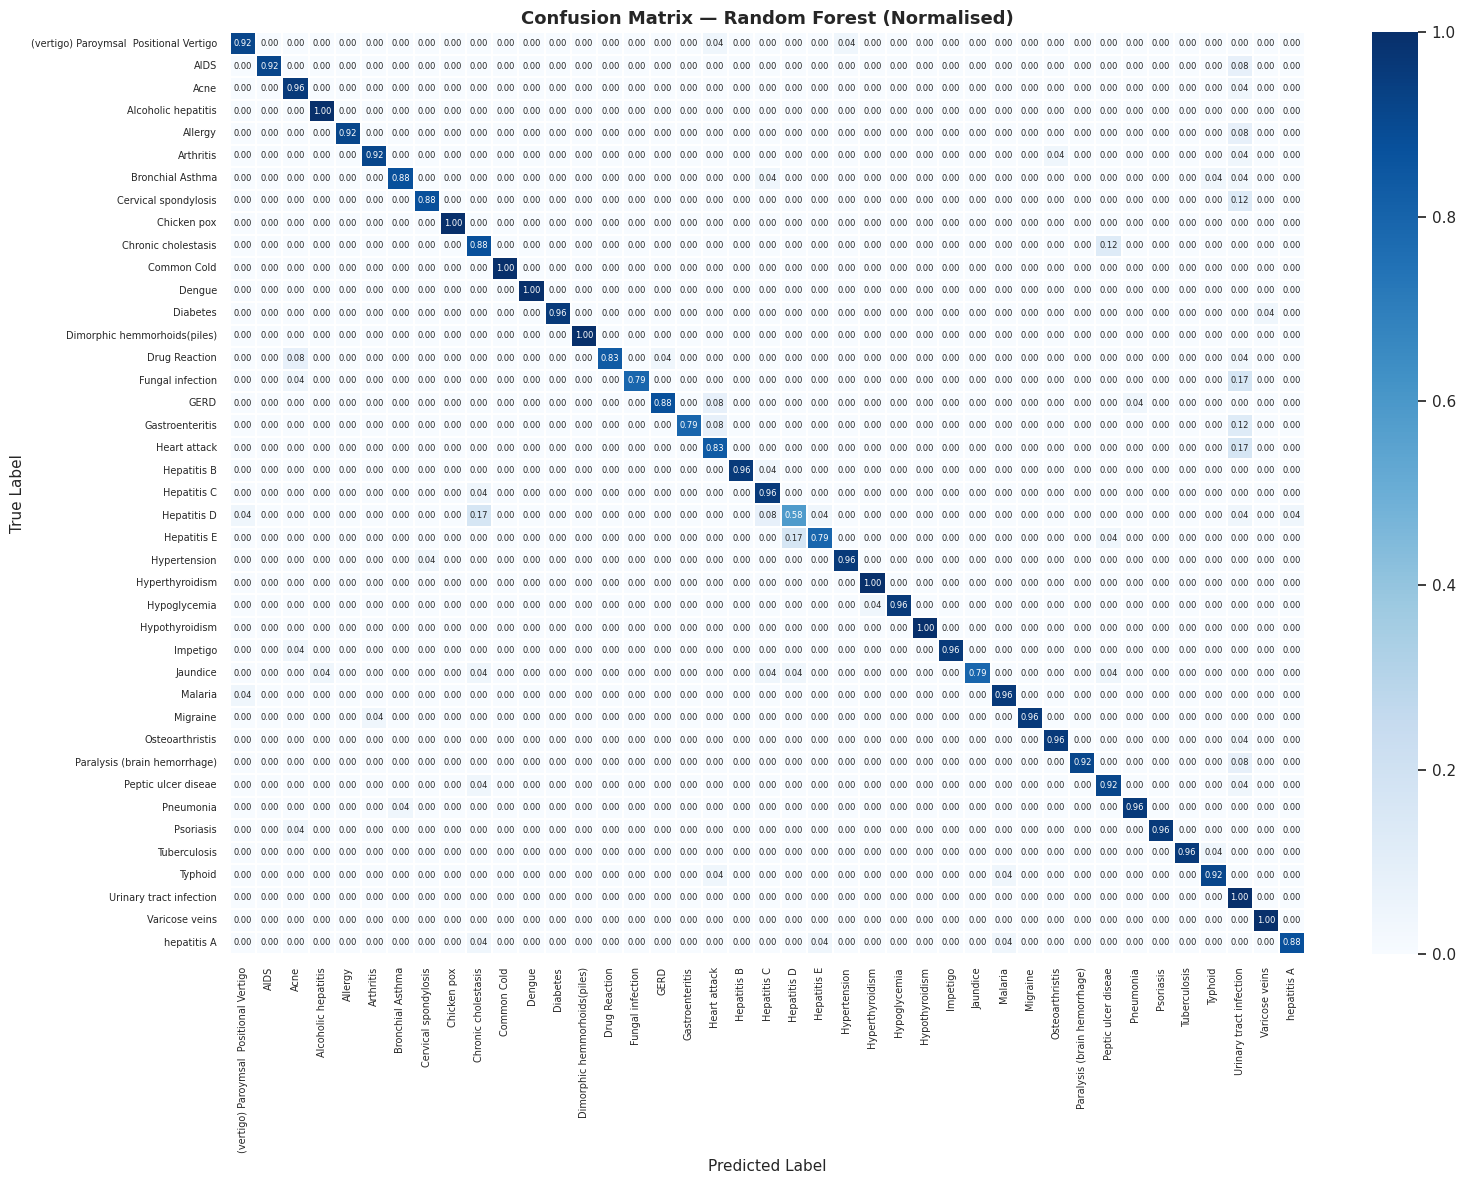

In [16]:
plot_confusion_matrix(y_test, rf_pred, le.classes_, 'Random Forest', 'cm_random_forest.png')

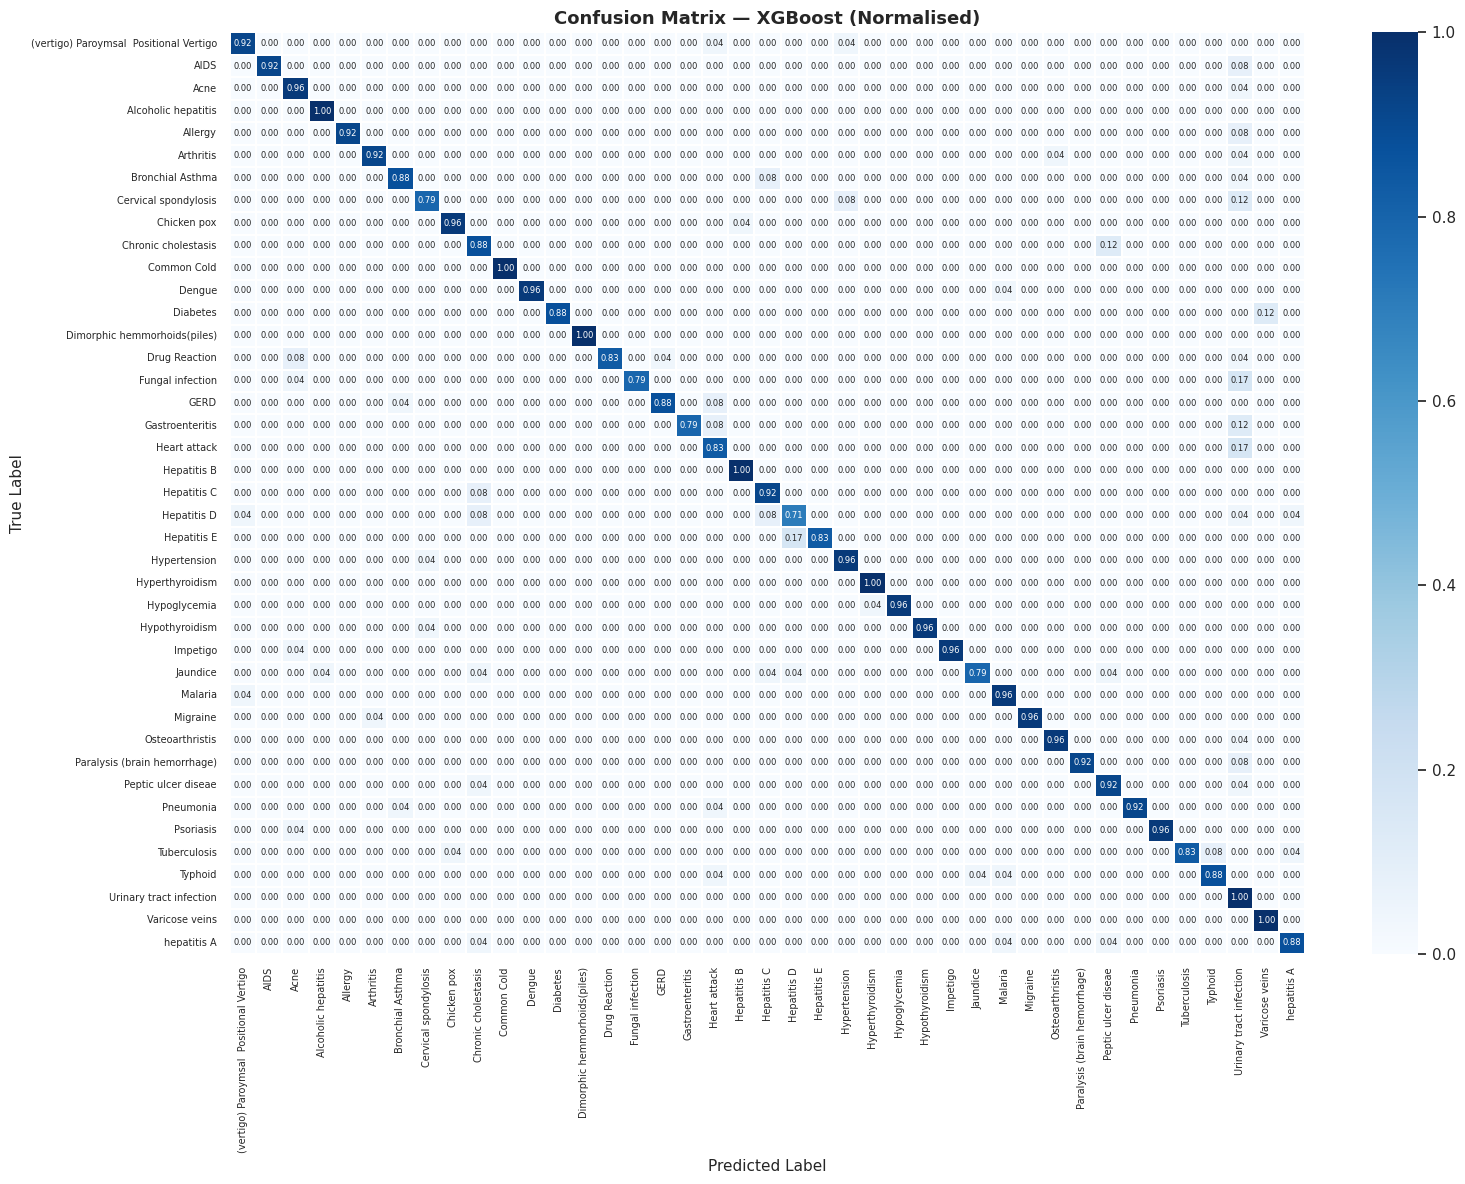

In [17]:
plot_confusion_matrix(y_test, xgb_pred, le.classes_, 'XGBoost', 'cm_xgboost.png')

## 9. Comparison of Models

In [18]:
results_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'XGBoost'],
    'Accuracy (%)': [
        round(dt_acc  * 100, 2),
        round(rf_acc  * 100, 2),
        round(xgb_acc * 100, 2)
    ]
}).sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)

results_df.index += 1
print(results_df.to_string())

           Model  Accuracy (%)
1  Random Forest         91.88
2        XGBoost         91.07
3  Decision Tree         87.72


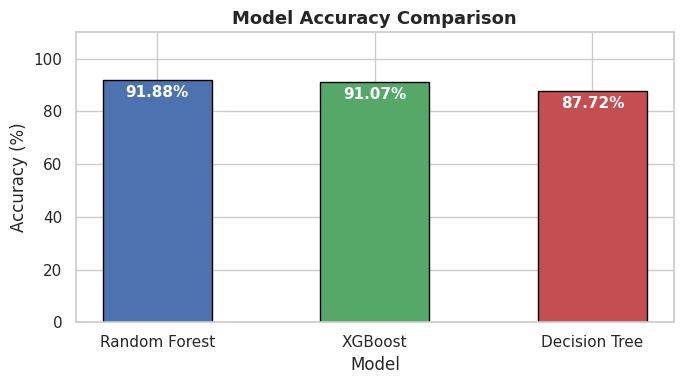

In [19]:
plt.figure(figsize=(7, 4))
bars = plt.bar(results_df['Model'], results_df['Accuracy (%)'],
               color=['#4C72B0', '#55A868', '#C44E52'], edgecolor='black', width=0.5)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h - 2,
             f'{h:.2f}%', ha='center', va='top', fontsize=11, fontweight='bold', color='white')

plt.title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 110)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

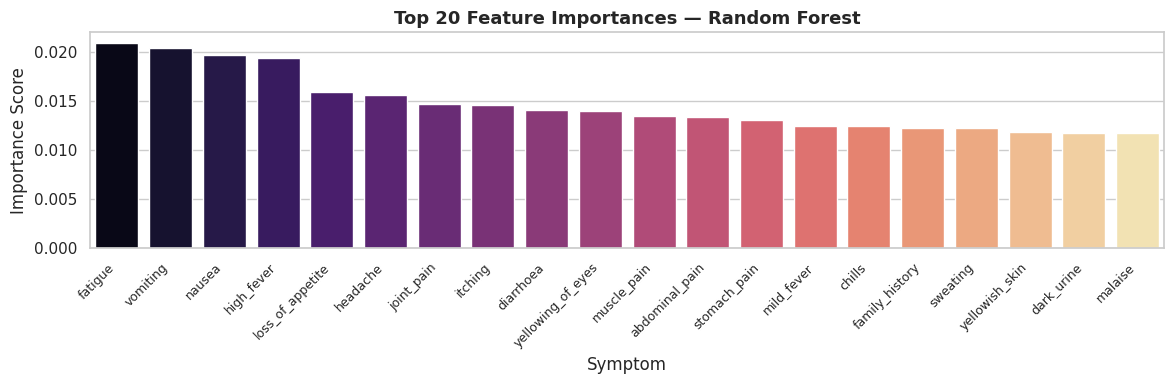

In [20]:
# Feature importance — Random Forest (top 20)
importances = rf_model.feature_importances_
feat_names  = np.array(selected_features)
indices     = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(12, 4))
sns.barplot(x=feat_names[indices], y=importances[indices], palette='magma')
plt.title('Top 20 Feature Importances — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Symptom')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Conclusion
All three models were trained and evaluated on the severity-weighted disease prediction dataset. Ensemble methods (Random Forest, XGBoost) outperformed the single Decision Tree, demonstrating the advantage of ensemble learning for medical classification tasks.

In [21]:
print('=' * 50)
print('       DISEASE PREDICTION SYSTEM — RESULTS')
print('=' * 50)
print(f'  Decision Tree Accuracy : {dt_acc  * 100:.2f}%')
print(f'  Random Forest Accuracy : {rf_acc  * 100:.2f}%')
print(f'  XGBoost Accuracy       : {xgb_acc * 100:.2f}%')
print('=' * 50)
best = results_df.iloc[0]
print(f'  Best Model: {best["Model"]} ({best["Accuracy (%)"]:.2f}%)')
print('=' * 50)

       DISEASE PREDICTION SYSTEM — RESULTS
  Decision Tree Accuracy : 87.72%
  Random Forest Accuracy : 91.88%
  XGBoost Accuracy       : 91.07%
  Best Model: Random Forest (91.88%)
